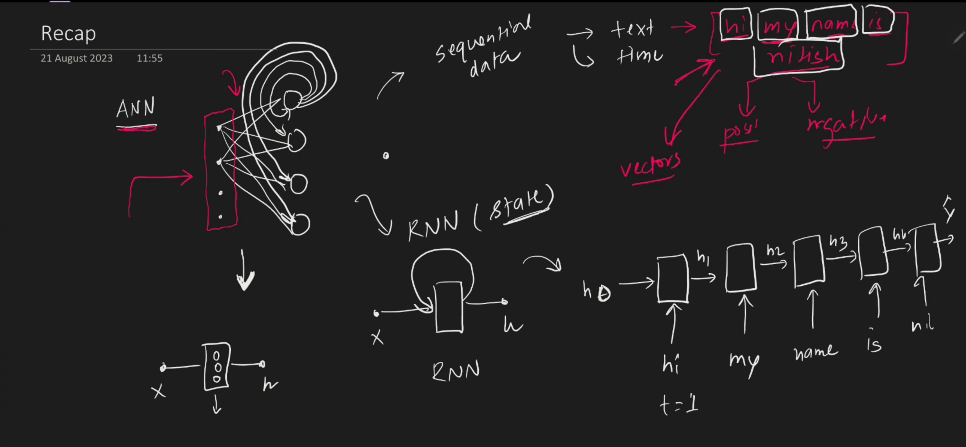

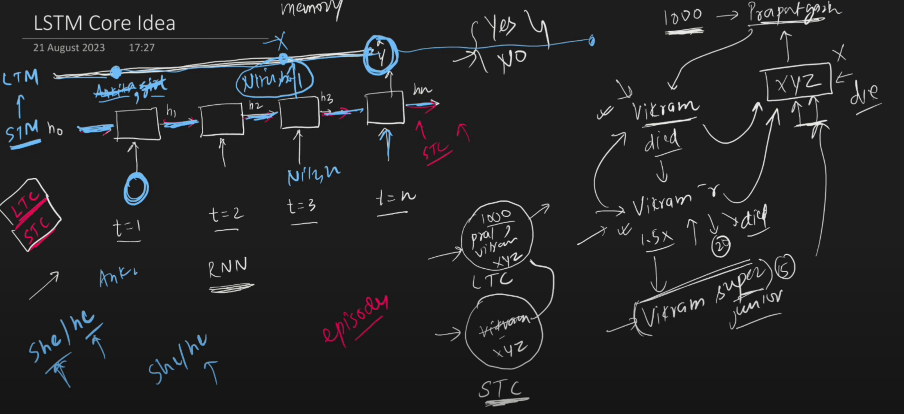

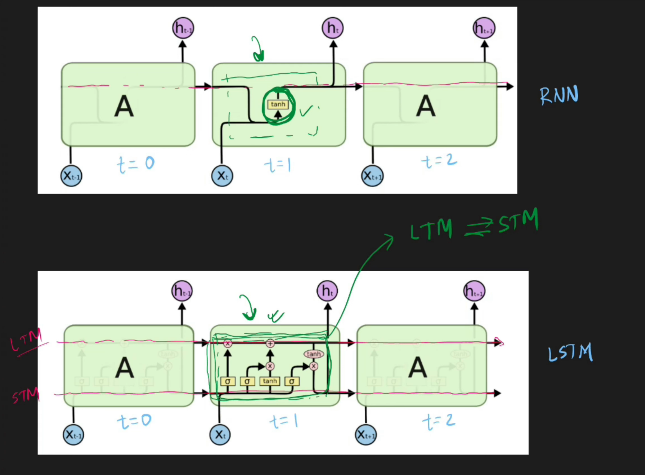

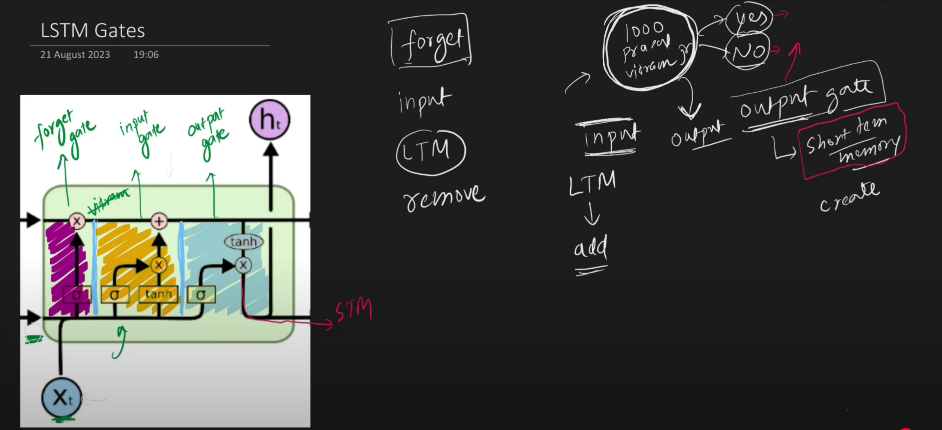

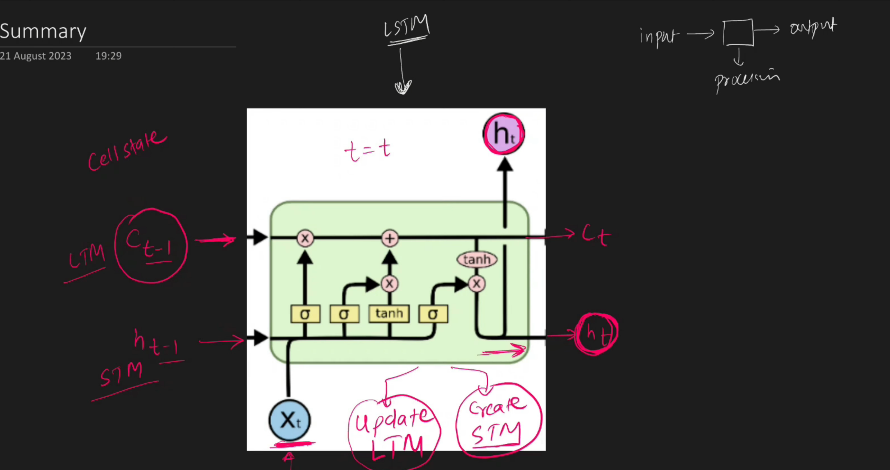



---

## 🧠 How to Think About LSTM: The Memory Engineer’s Mindset

You are designing a neural network that reads a novel — 300 pages long.

At page 290, it must answer:  
> “Why did Anna die?”

To answer correctly, it must remember:
- She was lonely (page 5)
- She fell in love (page 40)
- Her husband was cold (page 60)
- She took medicine (page 200)

A **vanilla RNN fails** — by page 290, those memories are **gone**.

Why? Because every time it updates its hidden state, it **transforms everything** through tanh and matrix multiplication.

It’s like copying a VHS tape 290 times — each copy is worse than the last.

So you, the **AI engineer**, ask:

> “How do I build a memory that doesn’t degrade?”

That’s **LSTM**.

---

## 🔧 The Core Idea: Don’t Rewrite Memory — Edit It

An RNN does this:
\[
h_t = \tanh(W h_{t-1} + U x_t)
\]
👉 It **overwrites** the entire memory at every step.

That’s dangerous. You lose control.

An **LSTM** says:  
> “I won’t overwrite. I’ll keep a **separate memory lane** — the **cell state** — and carefully edit it.”

So:

- **Cell State (Cₜ)** = Long-term memory (like a USB drive)
- **Hidden State (hₜ)** = Working memory (what you’re thinking now)

And to manage the cell state, you design **three smart gates**.

---

## 🔐 The Three Gates of LSTM

Think like a **security system** guarding a vault (the cell state).

### 1️⃣ Forget Gate: “What should I forget?”

At every time step, ask:  
> “Is this old memory still useful?”

\[
f_t = \sigma(W_f \cdot [h_{t-1}, x_t])
\]

- Output: number between 0 and 1 for each part of memory
- 0 = “forget completely”
- 1 = “keep forever”

👉 Like cleaning your desk: toss old papers, keep the contract.

🧠 *Example:* “The cat sat on the mat.” Later: “The dog barked.”  
→ You can **forget** “cat” and “mat” because new subject is “dog”.

---

### 2️⃣ Input Gate: “What new info is important?”

Not everything you see is worth remembering.

So:
\[
i_t = \sigma(W_i \cdot [h_{t-1}, x_t])
\]
\[
\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t])
\]

- \( i_t \): decides **how much** of the new info to store
- \( \tilde{C}_t \): the **candidate memory** — what you *might* remember

👉 Like a journalist deciding: “This quote is gold. Save it.”

🧠 *Example:* Hearing “climate change is accelerating” → mark as important.

---

### 3️⃣ Output Gate: “What should I say now?”

Finally, decide what to **output** and what to **carry forward**.

\[
o_t = \sigma(W_o \cdot [h_{t-1}, x_t])
\]
\[
h_t = o_t \cdot \tanh(C_t)
\]

- \( o_t \): decides what part of memory to **reveal**
- \( \tanh(C_t) \): the cleaned-up version of long-term memory

👉 Like a CEO giving a speech: shares only what’s relevant, not all internal data.

---

## 🧬 The Full LSTM Update

Now put it all together:

\[
C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t
\]
\[
h_t = o_t \odot \tanh(C_t)
\]

🔑 This is the **master equation**.

It says:
> New memory =  
> (what I keep from old memory) +  
> (what I add as new important info)

And the hidden state is a filtered view of that memory.

---

## 🌟 Why LSTM Solves Vanishing Gradient

Because of this line:

\[
C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t
\]

Look closely:  
There’s **no activation function** on \( C_{t-1} \).  
No tanh. No matrix multiplication. Just **copy or forget**.

So if \( f_t \approx 1 \), then:
\[
C_t \approx C_{t-1} + \text{new stuff}
\]

👉 The gradient flows **unchanged** through the cell state.

This is called the **Constant Error Carousel** — a highway for gradients.

Unlike RNN, where gradient gets multiplied by \( W^\top \tanh'(\cdot) \) at every step (→ vanishes), here it can pass through **intact**.

That’s why LSTM can learn dependencies over 100+ steps.

---

## 🛠️ Real-World Analogy: Your Phone

Think of your phone:

| LSTM Component | Phone Analogy |
|----------------|----------------|
| **Cell State (Cₜ)** | Cloud storage (Photos, Notes, Messages) |
| **Forget Gate** | Auto-delete old screenshots |
| **Input Gate** | Saving a new photo or note |
| **Output Gate** | What you show when someone borrows your phone |
| **Hidden State (hₜ)** | What’s on screen right now |

You don’t lose your old photos just because you opened WhatsApp.  
Same with LSTM — long-term memory is protected.

---

## 📈 When Was LSTM Born?

- **1997**: Hochreiter & Schmidhuber publish LSTM
- **2000s–2010s**: Dominates speech recognition, machine translation
- **2016**: Google Translate switches to LSTM
- **2017+**: Transformers rise, but LSTM still used in edge devices, time series, speech

---

## 🧭 The Engineer’s Mindset

As the **best AI engineer**, you don’t just use models — you **design memory**.

You ask:
- What should be remembered?
- What should be forgotten?
- How to protect important signals?

LSTM is not magic.  
It’s **intentional memory engineering**.

---

## ✅ One-Sentence Mastery

> **LSTM is a memory cell with three control knobs — forget, input, and output — that allow gradients and information to flow unchanged over time, solving the vanishing gradient problem in RNNs.**

---





---

### 🧠 LSTM: The Memory That Learns to Forget

> *A network that remembers what matters.*

#### 🔹 Problem
RNNs forget long-term info because every step applies tanh → gradients vanish.

#### 🔹 Solution
LSTM introduces:
- A **cell state (Cₜ)** — long-term memory  
- Three **gates** — forget, input, output  
- No activation on memory flow → gradients survive

---

### 🔄 Core Flow (From Your Diagram)

```
[Forget Gate] → Cₜ₋₁ → [Keep or Delete]
           ↓
[Input Gate] → New Info → [Add to Memory]
           ↓
Cell State (Cₜ) = Keep + Add
           ↓
[Output Gate] → Output = Filtered(Cₜ)
```

---

### ⚙️ Gates Explained

| Gate | Purpose | Analogy |
|------|--------|--------|
| **Forget** | Decide what to erase | Clearing old files |
| **Input**  | Decide what to store | Saving new notes |
| **Output** | Decide what to show | Sharing only relevant facts |

Each gate uses sigmoid → outputs 0 to 1 (how much to keep/add).

---

### 💡 Why It Works

- Cell state flows **unchanged** through time.
- Gradient can pass through without vanishing.
- Like a **memory highway** with traffic lights.

👉 This is the **constant error carousel** — gradients don’t die.

---

### ✅ Summary

- RNN: memory fades over time  
- LSTM: memory survives with control  
- **Best for sequences**: text, speech, time series  




---

### 🔹 Q1: Why do we need LSTMs?

**A:**  
Because RNNs forget.  
When the gap between important information and where it’s needed is large (e.g., “I grew up in France… I speak fluent ___”), RNNs fail.  
LSTMs fix this by learning **what to remember, what to forget, and what to output** — so they can handle long-term dependencies.

---

### 🔹 Q2: What’s the core idea of LSTM?

**A:**  
Give the network a **protected memory lane** — the **cell state** — that flows unchanged unless explicitly edited.

Like a **conveyor belt** carrying facts through time.  
Gates decide what gets on, off, or stays.

---

### 🔹 Q3: What is the cell state?

**A:**  
It’s the **long-term memory** of the network.  
Unlike the hidden state in RNNs, it doesn’t get transformed at every step.  
It only changes when the gates allow — so information survives for hundreds of steps.

👉 Think: a USB drive that keeps data safe unless you choose to delete or update.

---

### 🔹 Q4: What are the three gates in LSTM?

**A:**  
Three smart filters that control the cell state:

1. **Forget Gate** → Decides what to erase  
   - “Was the subject male or female?” → When new subject comes, forget old gender.  
   - Output: 0 (forget) to 1 (keep)

2. **Input Gate** → Decides what new info to store  
   - “New subject is ‘Maria’ → she is female” → add this fact  
   - Works with a **candidate memory** (\( \tilde{C}_t \))

3. **Output Gate** → Decides what to reveal now  
   - Based on current input and past memory  
   - Outputs filtered version of cell state as \( h_t \)

---

### 🔹 Q5: How is the cell state updated?

**A:**  
In two steps:

1. **Forget old stuff**:  
   \[
   \text{Keep} = f_t \odot C_{t-1}
   \]

2. **Add new stuff**:  
   \[
   \text{Add} = i_t \odot \tilde{C}_t
   \]

Then combine:  
\[
C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t
\]

Simple. No activation. No distortion.  
Memory flows safely.

---

### 🔹 Q6: Why doesn’t gradient vanish in LSTM?

**A:**  
Because the cell state update is **additive and linear**.  
If the forget gate is close to 1, then:
\[
C_t \approx C_{t-1} + \text{new}
\]
So the gradient passes through unchanged — like a wire.

This is the **Constant Error Carousel**:  
Gradients don’t decay → long-term learning becomes possible.

---

### 🔹 Q7: How is LSTM different from RNN?

| Feature | RNN | LSTM |
|--------|-----|------|
| Memory | One hidden state | Cell state + hidden state |
| Update | Overwrite every step | Edit selectively |
| Gates | None | Three (forget, input, output) |
| Long-term memory | Poor (vanishes) | Strong (protected) |

👉 RNN = notebook you rewrite every day  
👉 LSTM = digital note app with folders, search, and undo

---

### 🔹 Q8: What’s the role of the hidden state?

**A:**  
The **working memory** — what the network is thinking *right now*.  
It’s derived from the cell state but filtered by the output gate.

Used to:
- Predict next word
- Pass to next time step
- Interact with input

So:  
- **Cell state (Cₜ)** = long-term storage  
- **Hidden state (hₜ)** = current thought

---

### 🔹 Q9: Are all LSTMs the same?

**A:**  
No. There are **variants**:

1. **Peephole Connections**: Gates can look at the cell state when making decisions.
2. **Coupled Forget & Input Gates**: Forget and input happen together — only forget if adding something new.
3. **GRU (Gated Recurrent Unit)**: Merges forget + input into one "update gate", and combines cell & hidden state → simpler, faster.

But all share the same idea: **controlled memory**.

---

### 🔹 Q10: What comes after LSTM?

**A:**  
**Attention**.

Instead of summarizing everything into a hidden state, attention lets the network **look back** at all previous inputs when making a decision.

Like reading a book and being allowed to flip back to any page — not just relying on memory.

This led to **Transformers**, which power models like GPT, BERT, and ChatGPT.

But LSTM was the **bridge** from simple RNNs to modern sequence models.

---

